In [1]:
!pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import joblib

In [3]:
df = pd.read_csv("/content/transactions_processed.csv")
df.head()

,user_id,transaction_date,hour_of_day,transaction_amount,merchant_category,transaction_timestamp,day_of_week,is_weekend,day_of_month,is_night_purchase,...,transaction_gap_variance,spend_spike_ratio,burst_score,night_spend_ratio,category_entropy,is_end_month,monthly_avg_spend,end_month_surge_index,behavioural_drift_score,high_impulse_event
0,user_0,2025-01-01,13,90.869306,entertainment,2025-01-01 13:00:00,2,False,1,False,...,0.00,0.989115,0.0,0.0,0.000000,False,94.932285,0.0,0.0,0
1,user_0,2025-01-05,4,116.611235,travel,2025-01-05 04:00:00,6,True,5,False,...,3784.50,1.113337,0.0,0.0,0.000000,False,94.932285,0.0,0.0,0
2,user_0,2025-01-06,19,47.091855,utilities,2025-01-06 19:00:00,0,False,6,False,...,1899.00,0.548489,0.0,0.0,0.000000,False,94.932285,0.0,0.0,0
3,user_0,2025-01-08,12,168.191071,food_delivery,2025-01-08 12:00:00,2,False,8,False,...,1266.25,1.576434,0.0,0.0,0.000000,False,94.932285,0.0,0.0,0
4,user_0,2025-01-09,0,72.929843,electronics,2025-01-09 00:00:00,3,False,9,True,...,1126.70,0.728289,0.0,0.2,1.609438,False,94.932285,0.0,0.0,0


In [4]:
user_df = df.groupby("user_id").agg({
    "spend_spike_ratio": "mean",
    "burst_score": "mean",
    "night_spend_ratio": "mean",
    "end_month_surge_index": "mean",
    "category_entropy": "mean",
    "behavioural_drift_score": "mean",
    "transaction_gap_variance": "mean"
}).reset_index()

user_df.head()

,user_id,spend_spike_ratio,burst_score,night_spend_ratio,end_month_surge_index,category_entropy,behavioural_drift_score,transaction_gap_variance
0,user_0,0.988290,0.054645,0.165865,0.275884,1.775566,-0.253575,479.089863
1,user_1,0.998079,0.107527,0.192173,0.233872,1.790039,0.579658,546.851464
2,user_10,0.992051,0.045455,0.456588,0.200443,1.788009,-0.025412,423.421798
3,user_100,1.001897,0.140625,0.178723,0.211766,1.808036,0.956463,411.783028
4,user_101,0.996160,0.084746,0.220673,0.155594,1.787395,-0.827139,462.715727


In [5]:
cluster_features = [
    "spend_spike_ratio",
    "burst_score",
    "night_spend_ratio",
    "end_month_surge_index",
    "category_entropy",
    "behavioural_drift_score",
    "transaction_gap_variance"
]

X_cluster = user_df[cluster_features]

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

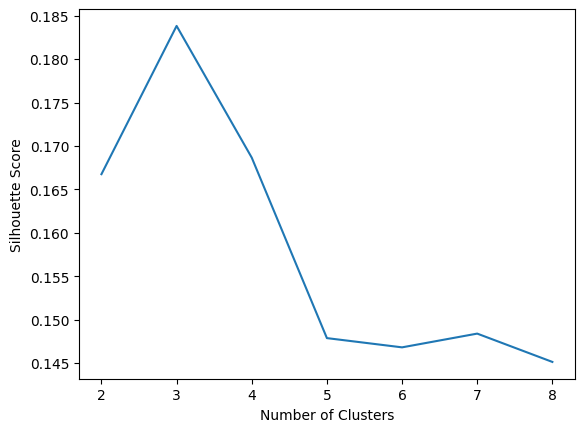

In [7]:
sil_scores = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.plot(k_values, sil_scores)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [8]:
optimal_k = 4

kmeans_model = KMeans(n_clusters=optimal_k, random_state=42)
user_df["cluster"] = kmeans_model.fit_predict(X_scaled)

In [9]:
cluster_summary = user_df.groupby("cluster")[cluster_features].mean()
cluster_summary

,spend_spike_ratio,burst_score,night_spend_ratio,end_month_surge_index,category_entropy,behavioural_drift_score,transaction_gap_variance
cluster,,,,,,,
0,0.990743,0.146277,0.451435,0.212670,1.771844,0.375896,582.347112
1,0.980618,0.110076,0.243304,0.173856,1.778061,-1.476073,552.653902
2,0.994119,0.100463,0.207063,0.204503,1.773341,0.951849,562.217955
3,0.990128,0.199071,0.213954,0.180545,1.803982,0.100257,367.343047


In [10]:
cluster_label_map = {
    0: "Stable Planner",
    1: "Night Impulse Buyer",
    2: "Salary Cycler",
    3: "Burst Spender"
}

user_df["personality"] = user_df["cluster"].map(cluster_label_map)

In [11]:
joblib.dump(kmeans_model, "clustering_model.pkl")
joblib.dump(scaler, "clustering_scaler.pkl")

user_df.to_csv("user_personality_profiles.csv", index=False)